# Flowmatching approach

In [ ]:
import os
import subprocess
def check_mig_with_smi():
    try:
        output = subprocess.check_output(["nvidia-smi", "-L"], text=True)
        return "MIG" in output
    except (subprocess.CalledProcessError, FileNotFoundError):
        return False

if check_mig_with_smi():
    print("Running on a GPU MIG instance")
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
else:
    print("Not running on a GPU MIG instance")

import matplotlib.pyplot as plt
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#1F1F1F'
plt.rcParams['axes.facecolor'] = '#1F1F1F'
plt.rcParams['savefig.facecolor'] = '#1F1F1F'

from torchvision.transforms import GaussianBlur
from scipy.ndimage import gaussian_filter
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import time

Not running on a GPU MIG instance


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
print(torch.cuda.is_available())

True


## Data

In [ ]:
import torch
import h5py
from torch.utils.data import Dataset
import numpy as np
from pathlib import Path
from dataloaders.utils import spatial_resample

class DiskDatasetDiv(Dataset):
    def __init__(self, preproc_path, temporal_bundling = 10, forward_steps = 1):
        self.filepath = preproc_path
        self._file = None
        # If the file ends with .h5, remove it
        if self.filepath.endswith('.h5'):
            self.filepath = self.filepath[:-3]
        metafile = Path(self.filepath)
        metafile = metafile / 'meta.h5'
        #check if metafile exists
        if not metafile.exists():
            raise FileNotFoundError(f"Metadata file {metafile} does not exist. Please preprocess the data first.")
        with h5py.File(metafile, 'r') as f:
            self.avg = float(f['avg'][()])
            self.std = float(f['std'][()])
            self.resample_shape = int(f['resample_shape'][()])
            self.resample_mode = str(f['resample_mode'][()].decode('utf-8'))
            self.dt = int(f['timesample'][()])
            self.name = str(f['name'][()].decode('utf-8'))
            self.traj = int(f['traj'][()])
            self.ts = int(f['ts'][()])
            self.datashape = tuple(f['datashape'][()])
        #print(f"Dataset {self.name} loaded with {self.traj} trajectories, each with {self.ts} time steps.")
        #print(f"reshape method: {self.resample_mode}, shape: {self.resample_shape}")
        self.tb = temporal_bundling
        self.fs = forward_steps
        self.lenpertraj = self.ts - (self.fs) * self.dt * self.tb + self.dt
        print(f"length per trajectory: {self.lenpertraj}, temporal bundling: {self.tb}, trajectories: {self.traj}")
        self.idx_window = self.dt * self.tb
        self.avgnorm = None
        self.stdnorm = None
        
    def __len__(self):
        return self.traj * self.lenpertraj

    def __getitem__(self, idx):
        
        #f = self._get_file()
        traj_idx = idx // self.lenpertraj
        ts_idx = idx % self.lenpertraj
        filename = self.filepath
        # if ends with .h5, remove it
        filename = Path(filename)
        filename = filename / f'traj{traj_idx:05d}.h5'
        with h5py.File(filename, 'r') as f:
            target = f['data'][ts_idx : ts_idx + self.idx_window : self.dt]
            #label = f['data'][ts_idx + self.fs * self.idx_window : ts_idx + (self.fs + 1) * self.idx_window : self.dt]
        if self.avgnorm is not None:
            target = (target - self.avgnorm) / self.stdnorm
        #prior = self.prior_prefix(target, fromframe=4, sigma=4.5, scale=0.8)
        #prior = self.prior_prefix_timeindep(target, fromframe=3, sigma=4, scale=2.0)
        prior = self.prior_purenoise(target, fromframe=3)

        #label = (label - self.avgnorm) / self.stdnorm
        return torch.tensor(prior, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)
    
    def prior_purenoise(self, data, fromframe=4):
        # generate pure gaussian noise
        noise = np.random.normal(size=data[fromframe:].shape)
        prior = data.copy()
        prior[fromframe:] = noise
        return prior

    def get_single_traj(self, idx):
        #f = self._get_file()
        filename = self.filepath
        filename = Path(filename)
        filename = filename / f'traj{idx:05d}.h5'
        with h5py.File(filename, 'r') as f:
            full = f['data'][::self.dt]
        if self.avgnorm is not None:
            full = (full - self.avgnorm) / self.stdnorm
        return torch.tensor(full, dtype=torch.float32)

nw = 16
pw = True

#dataset = DiskDatasetDiv(preproc_path='../datasets/prjs1359/preproc_pdegym-test', temporal_bundling=21, forward_steps=1)
#dataset = DiskDatasetDiv(preproc_path='/data/fluidgpt/preproc_pdegym-test', temporal_bundling=21, forward_steps=1)
#dataset = DiskDatasetDiv(preproc_path='/home/developer/data/fluidgpt/preproc_pdegym-test', temporal_bundling=16, forward_steps=1)
dataset = DiskDatasetDiv(preproc_path='/data/fluidgpt/preproc_pdegym-test', temporal_bundling=16, forward_steps=1)
dataloader1 = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=nw, pin_memory=True, persistent_workers=pw)

ntiny = 128
dataset_tiny = torch.utils.data.Subset(dataset, random.sample(range(len(dataset)), ntiny))
dataloader2 = DataLoader(dataset_tiny, batch_size=32, shuffle=True, pin_memory=True, num_workers=nw, persistent_workers=pw)
nmicro = 1
dataset_micro = torch.utils.data.Subset(dataset, random.sample(range(len(dataset)), nmicro))
#dataloader3 = DataLoader(dataset_micro, batch_size=nmicro, shuffle=True, pin_memory=True, num_workers=nw, persistent_workers=pw)

dataset_tiny.dataset.avgnorm = dataset_tiny.dataset.avg
dataset_tiny.dataset.stdnorm = dataset_tiny.dataset.std
dataset_micro.dataset.avgnorm = dataset_micro.dataset.avg
dataset_micro.dataset.stdnorm = dataset_micro.dataset.std
dataset_tiny.dataset.avgnorm, dataset_tiny.dataset.stdnorm

dataloader = dataloader2
len(dataloader)


length per trajectory: 6, temporal bundling: 16, trajectories: 1177


4

prior acquired


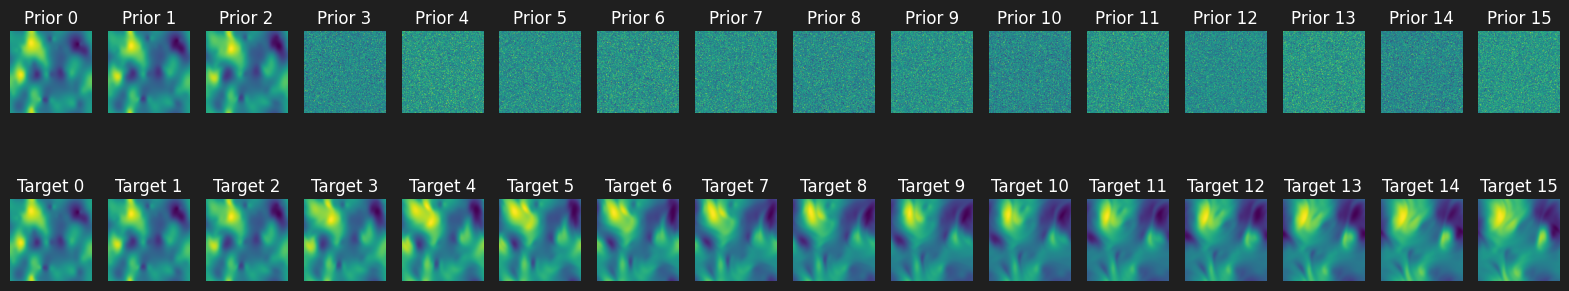

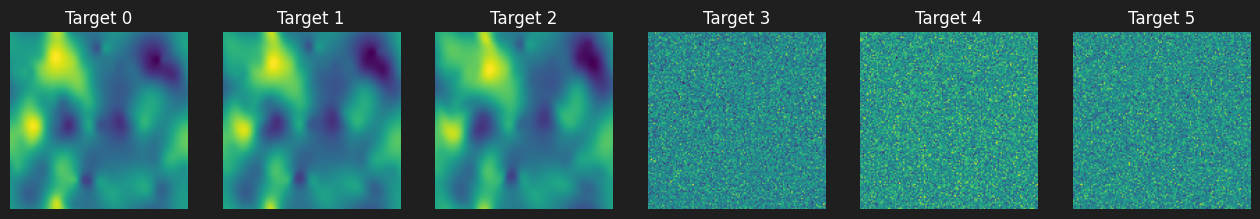

In [ ]:
for prior, target in dataloader:
    imagescount = prior.shape[1]
    break
print('prior acquired')
fig, ax = plt.subplots(2, imagescount, figsize=(20, 4))
for i in range(imagescount):
    ax[0, i].imshow(prior[0, i, 0].cpu().numpy(), cmap='viridis')
    ax[0, i].set_title(f'Prior {i}')
    ax[0, i].axis('off')
    ax[1, i].imshow(target[0, i, 0].cpu().numpy(), cmap='viridis')
    ax[1, i].set_title(f'Target {i}')
    ax[1, i].axis('off')
fig, ax = plt.subplots(1,6, figsize=(16, 8))
for i in range(6):
    ax[i].imshow(prior[0, i, 0].cpu().numpy(), cmap='viridis')
    ax[i].set_title(f'Target {i}')
    ax[i].axis('off')

In [ ]:
"""
class SpatioTemporalAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder: [B, 20, 2, 128, 128] -> treat time as depth in Conv3D
        # Conv3D expects input as [B, C, T, H, W], so we swap dims first
        self.encoder = nn.Sequential(
            # Downsample time by 2 (20→10) and space by 2 (128→64)
            nn.Conv3d(2, 16, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.ReLU(inplace=True),
            # Downsample time by 2 again (10→5) and space by 2 (64→32)
            nn.Conv3d(16, 2, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Decoder: reverse the process (optional if you only want encoder output)
        self.decoder = nn.Sequential(
            # Upsample time 5→10, space 32→64
            nn.ConvTranspose3d(2, 16, kernel_size=4, stride=(2, 2, 2), padding=1),
            nn.ReLU(inplace=True),
            # Upsample time 10→20, space 64→128
            nn.ConvTranspose3d(16, 2, kernel_size=4, stride=(2, 2, 2), padding=1),
        )

    def forward(self, x):
        # x: [B, T, C, H, W] -> rearrange for Conv3D
        x = x.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
        bottleneck = self.encoder(x)   # [B, 2, 5, 32, 32]
        out = self.decoder(bottleneck) # [B, 2, 20, 128, 128]
        out = out.permute(0, 2, 1, 3, 4) # Back to [B, T, C, H, W]
        return bottleneck.permute(0, 2, 1, 3, 4), out

# Example usage
B = 4
x = torch.randn(B, 20, 2, 128, 128)
model = SpatioTemporalAutoencoder()
bottleneck, recon = model(x)
"""

'\nclass SpatioTemporalAutoencoder(nn.Module):\n    def __init__(self):\n        super().__init__()\n\n        # Encoder: [B, 20, 2, 128, 128] -> treat time as depth in Conv3D\n        # Conv3D expects input as [B, C, T, H, W], so we swap dims first\n        self.encoder = nn.Sequential(\n            # Downsample time by 2 (20→10) and space by 2 (128→64)\n            nn.Conv3d(2, 16, kernel_size=3, stride=(2, 2, 2), padding=1),\n            nn.ReLU(inplace=True),\n            # Downsample time by 2 again (10→5) and space by 2 (64→32)\n            nn.Conv3d(16, 2, kernel_size=3, stride=(2, 2, 2), padding=1),\n            nn.ReLU(inplace=True)\n        )\n\n        # Decoder: reverse the process (optional if you only want encoder output)\n        self.decoder = nn.Sequential(\n            # Upsample time 5→10, space 32→64\n            nn.ConvTranspose3d(2, 16, kernel_size=4, stride=(2, 2, 2), padding=1),\n            nn.ReLU(inplace=True),\n            # Upsample time 10→20, space 64→128

In [ ]:
def timestep_embedding(timesteps, dim, max_period=10000):
    half = dim // 2
    freqs = torch.exp(-torch.arange(0, half, dtype=torch.float32, device=timesteps.device) * (math.log(max_period) / half))
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = F.pad(embedding, (0, 1))
    return embedding

class DoubleConv3D(nn.Module):
    def __init__(self, in_channels, out_channels, flowtime_embed_dim=None):
        super().__init__()
        self.use_time = flowtime_embed_dim is not None
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            #nn.BatchNorm3d(out_channels),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.GELU(),

            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            #nn.BatchNorm3d(out_channels),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.GELU(),
        )

        if self.use_time:
            self.time_mlp = nn.Sequential(
                nn.Linear(flowtime_embed_dim, out_channels * 2),
                nn.SiLU()
            )

    def forward(self, x, t_emb=None):
        out = self.conv(x)
        if self.use_time and t_emb is not None:
            gamma, beta = self.time_mlp(t_emb).chunk(2, dim=1)
            gamma = gamma[:, :, None, None, None]
            beta = beta[:, :, None, None, None]
            out = out * (1 + gamma) + beta
        return out

"""
class DoubleConv3D(nn.Module):
    def __init__(self, in_channels, out_channels, flowtime_embed_dim=None, num_groups=4):
        super().__init__()
        self.use_time = flowtime_embed_dim is not None

        # First conv
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(num_groups=num_groups, num_channels=out_channels)
        self.act1 = nn.GELU()

        # Second conv
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups=num_groups, num_channels=out_channels)
        self.act2 = nn.GELU()

        # Residual path
        self.residual = (
            nn.Conv3d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

        # Optional time embedding for FiLM conditioning
        if self.use_time:
            self.time_mlp = nn.Sequential(
                nn.Linear(flowtime_embed_dim, out_channels * 2),
                nn.SiLU()
            )

    def forward(self, x, t_emb=None):
        residual = self.residual(x)

        # First conv + norm + (optional) time conditioning
        out = self.conv1(x)
        out = self.norm1(out)
        if self.use_time and t_emb is not None:
            gamma, beta = self.time_mlp(t_emb).chunk(2, dim=1)
            gamma = gamma[:, :, None, None, None]
            beta = beta[:, :, None, None, None]
            out = out * (1 + gamma) + beta
        out = self.act1(out)

        # Second conv + norm + (optional) time conditioning
        out = self.conv2(out)
        out = self.norm2(out)
        if self.use_time and t_emb is not None:
            gamma, beta = self.time_mlp(t_emb).chunk(2, dim=1)
            gamma = gamma[:, :, None, None, None]
            beta = beta[:, :, None, None, None]
            out = out * (1 + gamma) + beta
        out = self.act2(out)

        return out + residual

"""

class UNet3D(nn.Module):
    def __init__(self, in_channels, out_channels, base_channels=64, mult = [1,2,2,2,2,2,1], flowtime_embed_dim=128):
        super().__init__()

        self.flowtime_embed_dim = flowtime_embed_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(flowtime_embed_dim, flowtime_embed_dim),
            nn.SiLU(),
            nn.Linear(flowtime_embed_dim, flowtime_embed_dim),
        )

        self.enc1 = DoubleConv3D(in_channels, base_channels * mult[0], flowtime_embed_dim)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3D(base_channels * mult[0], base_channels * mult[1], flowtime_embed_dim)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3D(base_channels * mult[1], base_channels * mult[2], flowtime_embed_dim)
        self.pool3 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_channels * mult[2], base_channels * mult[3], flowtime_embed_dim)

        self.up3 = nn.ConvTranspose3d(base_channels * mult[3], base_channels * mult[4], kernel_size=2, stride=2)
        self.dec3 = DoubleConv3D(base_channels * mult[4] + base_channels * mult[2], base_channels * mult[4], flowtime_embed_dim)
        self.up2 = nn.ConvTranspose3d(base_channels * mult[4], base_channels * mult[5], kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_channels * mult[5] + base_channels * mult[1], base_channels * mult[5], flowtime_embed_dim)
        self.up1 = nn.ConvTranspose3d(base_channels * mult[5], base_channels * mult[6], kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_channels * mult[6] + base_channels * mult[0], base_channels * mult[6], flowtime_embed_dim)

        self.out_conv = nn.Conv3d(base_channels * mult[6], out_channels, kernel_size=1)

    def forward(self, x, tf):
        B, T, C, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4) 

        t_emb = timestep_embedding(tf, self.flowtime_embed_dim)
        t_emb = self.time_mlp(t_emb)

        x1 = self.enc1(x, t_emb)
        x2 = self.enc2(self.pool1(x1), t_emb)
        x3 = self.enc3(self.pool2(x2), t_emb)
        x4 = self.bottleneck(self.pool3(x3), t_emb)
        #print(x3.shape)
        x = self.up3(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.dec3(x, t_emb)
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x, t_emb)
        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x, t_emb)

        x = self.out_conv(x)
        return x.permute(0, 2, 1, 3, 4) 


in_channels = 2
out_channels = in_channels

model = UNet3D(in_channels=in_channels, out_channels=out_channels, base_channels=128, mult = [1,2,2,2,2,2,1], flowtime_embed_dim=512)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.MSELoss()

xtest = torch.randn(1, imagescount, 2, 128, 128).to(device) 
t = torch.tensor([0.5]).cuda()

ytest = model(xtest, t)
print(f"Model output shape: {ytest.shape}")
# amount of param
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")

Model output shape: torch.Size([1, 16, 2, 128, 128])
Model has 6392130 trainable parameters


## Training

Epoch 0 Loss: 0.163723, LR: 0.000500


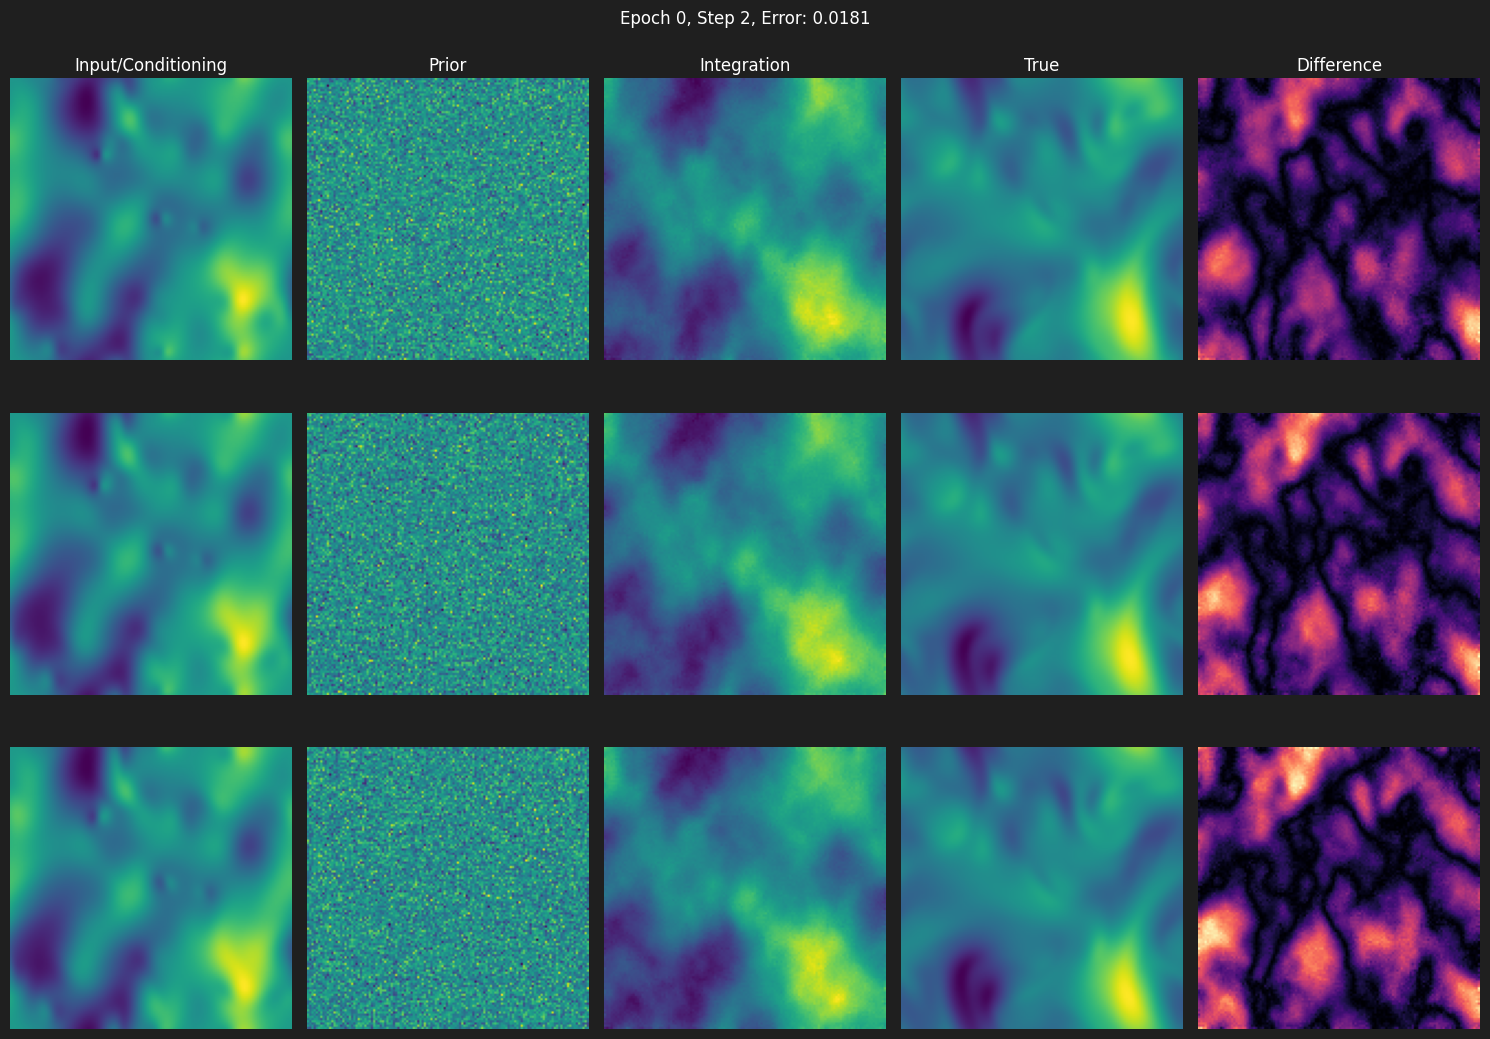

Epoch 1 Loss: 0.062952, LR: 0.000500


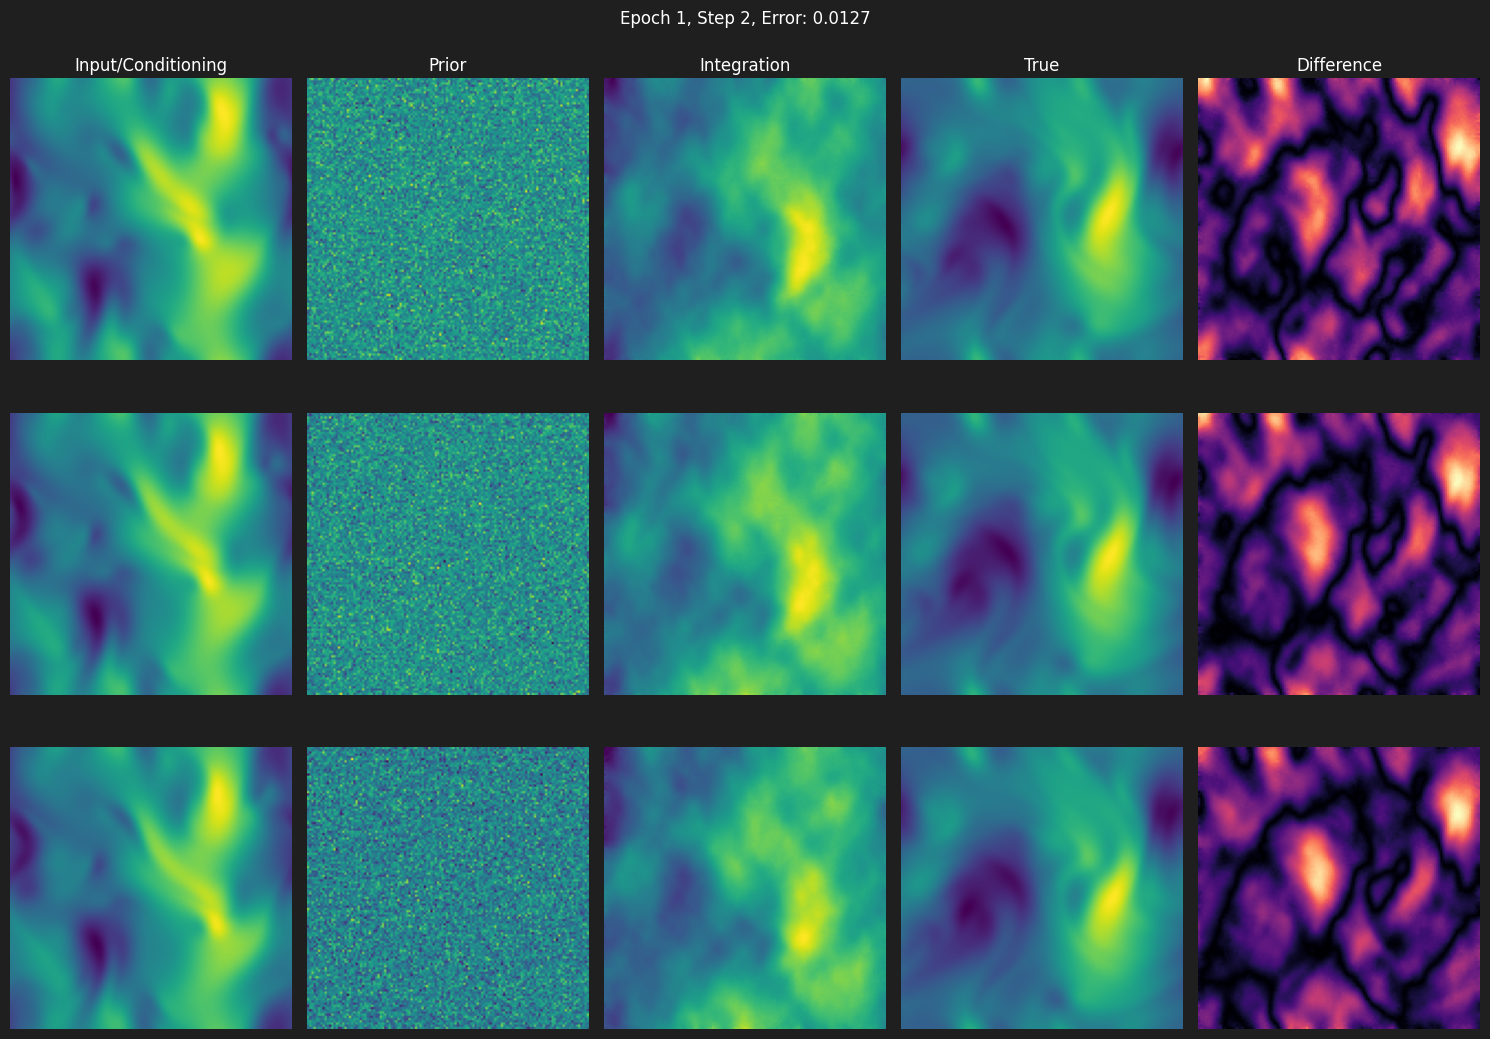

Epoch 2 Loss: 0.047186, LR: 0.000500


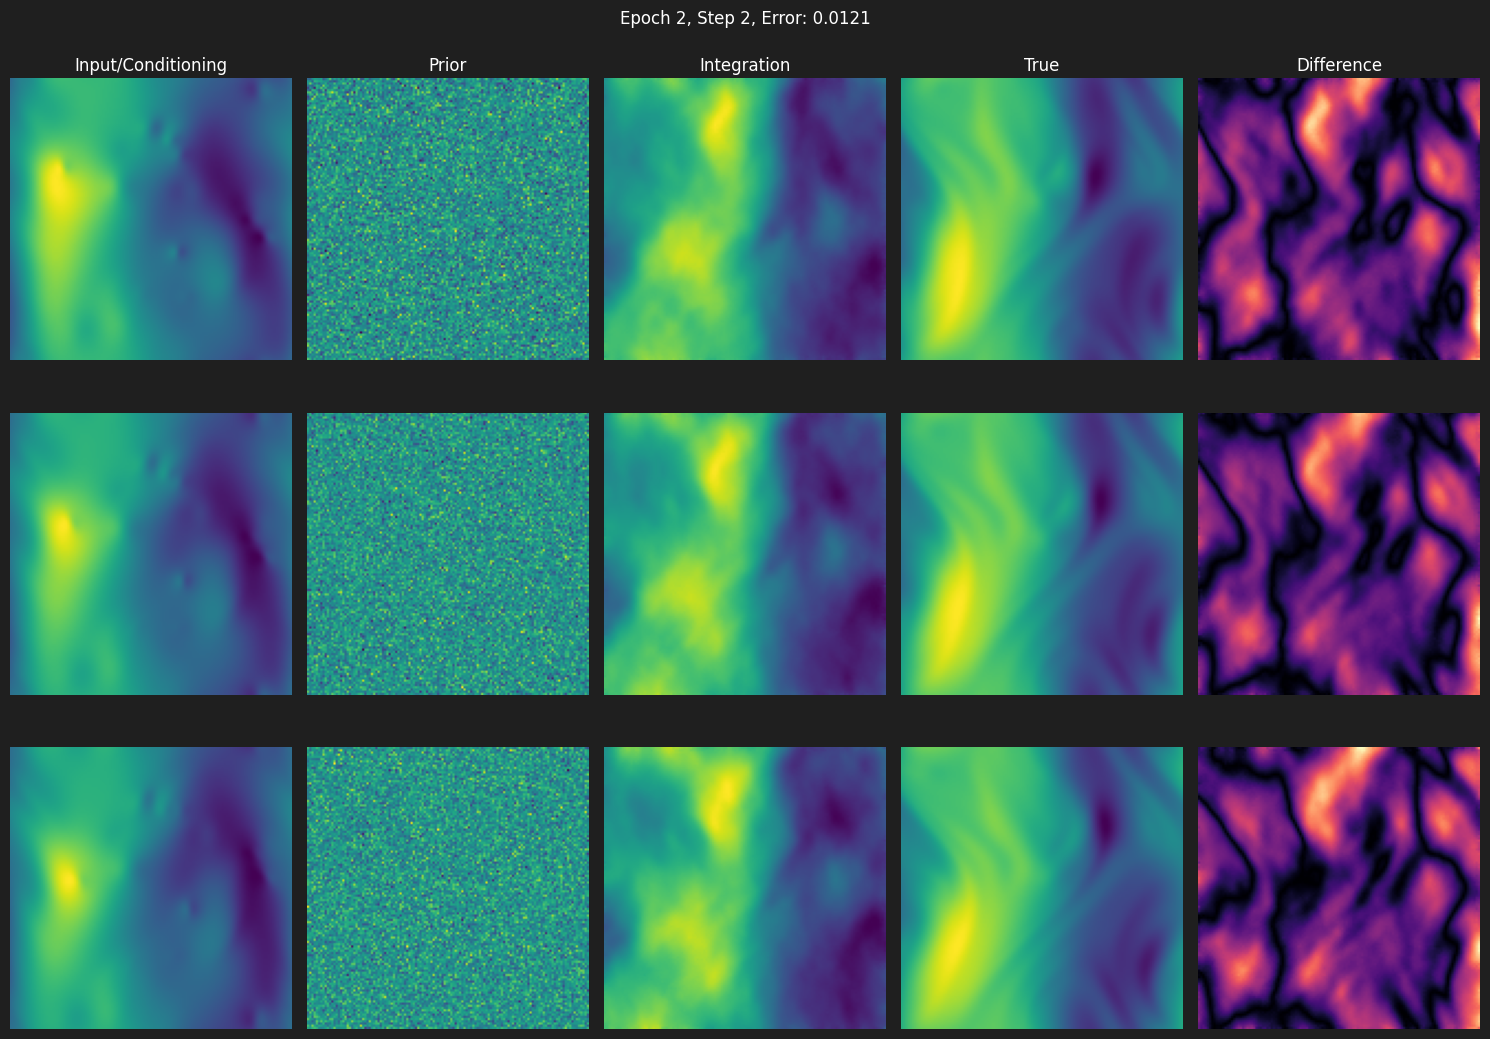

KeyboardInterrupt: 

In [ ]:
training_steps = 50#25000
epochs = 10
ratio = 1
eps = 0.001
steps = 25 #25
index_to_plot = -4 
optimizer = optim.Adam(model.parameters(), lr=1e-3) #try Adam instead of AdamW
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=5, min_lr=1e-5
)
losses = []
for epoch in range(epochs):
    epoch_losses = []
    model.train()
    for j in range(training_steps):
        for prior, target in dataloader:
            prior, target = prior.cuda(), target.cuda()
            optimizer.zero_grad()
            
            tf = torch.rand(target.shape[0], device=target.device) #* (1 - eps) + eps
            t_expand = tf.view(-1, 1, 1, 1, 1).repeat(
                        1, target.shape[1], target.shape[2], target.shape[3], target.shape[4]
                    )
            xt = t_expand * target.clone() + (1 - t_expand) * prior.clone()
            target_vector = target.clone() - prior.clone()

            pred = model(xt, tf)
            loss = ((pred - target_vector)**2).mean()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            epoch_losses.append(loss.item())
        if j % 10 == 0:
            print(f"Step {j} | Loss: {loss.item():.6f} ", end='\r')
    print(" ", end='\r')
    print(f"Epoch {epoch} Loss: {np.mean(epoch_losses):.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
            
    model.eval()
    with torch.no_grad():
        for prior, target in dataloader:
            prior, target = prior.cuda(), target.cuda()

            xt = prior.clone()  
            for tf in torch.linspace(0, 1 - 1/steps, steps):
                pred = model(xt, tf.expand(xt.size(0)).cuda())  # Predict the next step
                xt = xt.clone() + (1 / steps) * pred

            xt = xt.detach().cpu().numpy()
            prior = prior.detach().cpu().numpy()
            target = target.detach().cpu().numpy()

            fig, ax = plt.subplots(3, 5, figsize=(15, 11))

            for i in range(3):
                for j in range(5):
                    ax[i, j].axis('off')
                #ax[i].axis('off')
                ax[i,0].imshow(prior[0, i, 0])
                ax[i,1].imshow(prior[0, index_to_plot + i, 0])
                ax[i,2].imshow(xt[0, index_to_plot + i, 0])
                ax[i,3].imshow(target[0, index_to_plot + i, 0])
                ax[i,4].imshow(np.abs(target[0, index_to_plot + i, 0] - xt[0, index_to_plot + i, 0]), cmap='magma')

            ax[0,0].set_title('Input/Conditioning')
            ax[0,1].set_title('Prior')
            ax[0,2].set_title('Integration')
            ax[0,3].set_title('True')
            ax[0,4].set_title('Difference')
            plt.suptitle(f'Epoch {epoch}, Step {i}, Error: {np.mean(np.abs(target[0, 0, 0] - xt[0, 0, 0])):.4f}')# | Integration Time: {integration_time:.2f}s')
            plt.tight_layout()
            plt.show()
            break
    scheduler.step(np.mean(epoch_losses))

In [ ]:

#torch.cuda.empty_cache()
assert 1 == 2, "Stop running here"

AssertionError: Stop running here

In [ ]:
filter = GaussianBlur(kernel_size=(5, 5), sigma=1.0)
x = torch.randn(1, 2, 2, 128, 128)
# fuse the first two dimensions
x = x.view(1, 2 * 2, 128, 128)
x_blurred = filter(x)

print(x_blurred.shape)

torch.Size([1, 4, 128, 128])


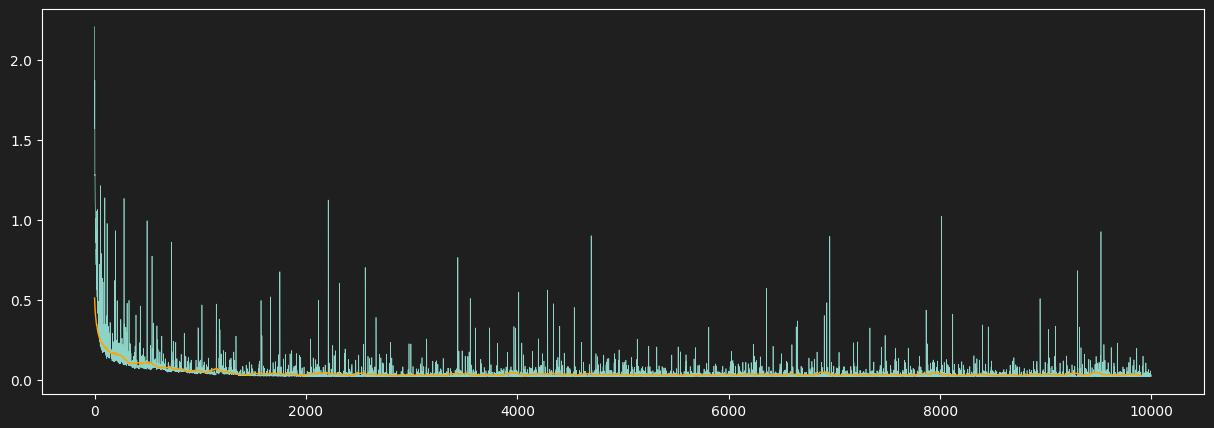

In [ ]:
# plot losses
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(losses, linewidth=0.5)
# plot average filter
# plot average filter of the losses without pandas
ax.plot([sum(losses[i:i+100])/100 for i in range(len(losses)-100)], linewidth=1, color='orange')
#ax.set_ylim(0, 4)


In [ ]:
# lower learning rate manually
#optimizer.param_groups[0]['lr'] = optimizer.param_groups[0]['lr'] * 10000
for y in dataloader:
    print(y.mean(), y.std())

tensor(-6.9849e-09) tensor(1.)


## Inference

In [ ]:
model.eval()
shape = torch.Size([64, 2, 2, 128, 128])
steps = 40
'''
for x, y in dataloader:
    x, y = x.cuda(), y.cuda()
    print(x.std(), x.mean())
    xnoise = random_fft_perturb(x, perturbation_strength=ratio)
    print(xnoise.std(), xnoise.mean())
    break  

xt = xnoise.clone()
'''
with torch.no_grad():
    for y in dataloader:
        y = y.cuda()
        print(y.std(), y.mean())
        xnoise = torch.randn_like(y, device=y.device)
        #xnoise = random_fft_perturb(y, perturbation_strength=ratio)
        #xnoise = random.uniform(-1, 1) * torch.ones_like(y, device=y.device)
        #xnoise = random.normalvariate(0, 1) * torch.ones_like(y, device=y.device)  # Initial noise
        #xnoise = torch.zeros_like(y, device=y.device)  #torch.randn_like(y, device=y.device) * ratio
        print(xnoise.std(), xnoise.mean())
    print("Integrating...")
    xt = xnoise.clone()  # Start from noise
    for i, t in enumerate(torch.linspace(0, 1, steps), start=1):
        pred = model(xt, t.expand(xt.size(0)).cuda())  # Predict the next step
        xt = xt + (1 / steps) * pred
        print(f"Sampling step {i}/{steps} done", end='\r')

print("Done Sampling")

tensor(1., device='cuda:0') tensor(0., device='cuda:0')
tensor(1.0010, device='cuda:0') tensor(-0.0038, device='cuda:0')
Integrating...
Done Sampling 40/40 done


In [ ]:
print(xt.shape)
xt = xt.detach().cpu().numpy()
xnoise = xnoise.detach().cpu().numpy()
#x = x.cpu().numpy()
y = y.detach().cpu().numpy()

torch.Size([1, 1, 2, 128, 128])


Input Noise mean and std -0.0038118744 1.0009604


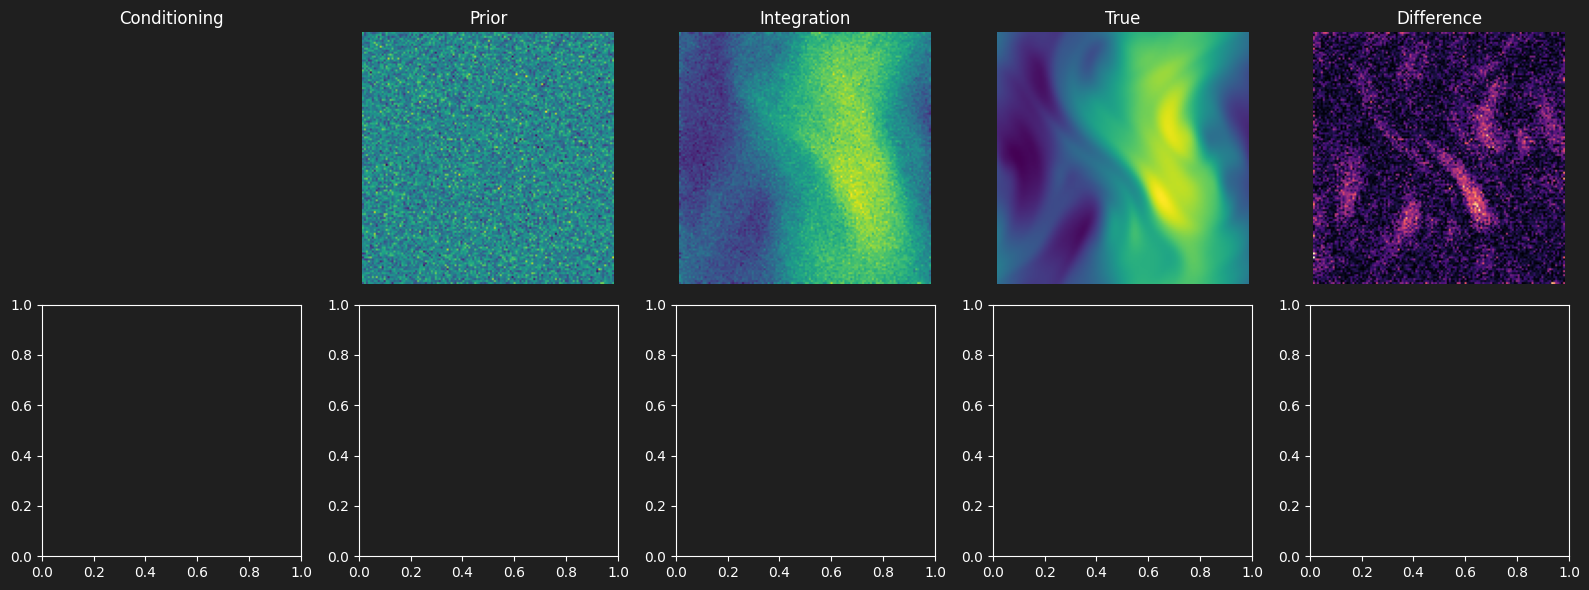

In [ ]:
items = 2
fig, ax = plt.subplots(items, 5, figsize=(16, 3 * items))
for i in range(items):
    # turn axis off
    ax[i, 0].axis('off')
    ax[i, 1].axis('off')
    ax[i, 2].axis('off')
    ax[i, 3].axis('off')
    ax[i, 4].axis('off')
    ax[i, 1].imshow(xnoise[0, i, 0])
    ax[i, 2].imshow(xt[0, i, 0])
    ax[i, 3].imshow(y[0, i, 0])
    ax[i, 4].imshow(np.abs(y[0, i, 0] - xt[0, i, 0]), cmap='magma')
    break
ax[0, 0].set_title('Conditioning')
ax[0, 1].set_title('Prior')
ax[0, 2].set_title('Integration')
ax[0, 3].set_title('True')
ax[0, 4].set_title('Difference')
print('Input Noise mean and std', xnoise.mean(), xnoise.std())
plt.tight_layout()

In [ ]:
model

SimpleUNet(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(45, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
      (4): BatchNorm2

In [ ]:
model.eval().requires_grad_(False)
shape = torch.Size([64, 2, 2, 128, 128])
for x, y in dataloader:
    x, y = x.cuda(), y.cuda()
    print(x.std(), x.mean())
    # take first element of batch
    x = x[0].repeat(8, 1, 1, 1, 1)
    y = y[0].repeat(8, 1, 1, 1, 1)
    xnoise = random_fft_perturb(x, perturbation_strength=ratio)
    break
steps = 100
xt = xnoise.clone()

print("Integrating...")
for i, t in enumerate(torch.linspace(0, 1, steps), start=1):
    pred = model(xt, t.expand(xt.size(0)).cuda())  
    xt = xt + (1 / steps) * pred
    print(f"Sampling step {i}/{steps} done", end='\r')
model.train().requires_grad_(True)

xt = xt.cpu().numpy()
xnoise = xnoise.cpu().numpy()
x = x.cpu().numpy()
y = y.cpu().numpy()

fig, ax = plt.subplots(4, 5, figsize=(16, 18))
for i in range(4):
    ax[i, 0].axis('off')
    ax[i, 1].axis('off')
    ax[i, 2].axis('off')
    ax[i, 3].axis('off')
    ax[i, 4].axis('off')
    ax[i, 0].imshow(x[i, 0, 0])
    ax[i, 1].imshow(xnoise[i, 0, 0])
    ax[i, 2].imshow(xt[i, 0, 0])
    ax[i, 3].imshow(y[i, 0, 0])
    ax[i, 4].imshow(np.abs(y[i, 0, 0] - xt[i, 0, 0]), cmap='magma')
ax[0, 0].set_title('Input')
ax[0, 1].set_title('Input Noise')
ax[0, 2].set_title('Flowmatched Output')
ax[0, 3].set_title('Target')
ax[0, 4].set_title('Difference')

plt.tight_layout()

ValueError: not enough values to unpack (expected 2, got 1)

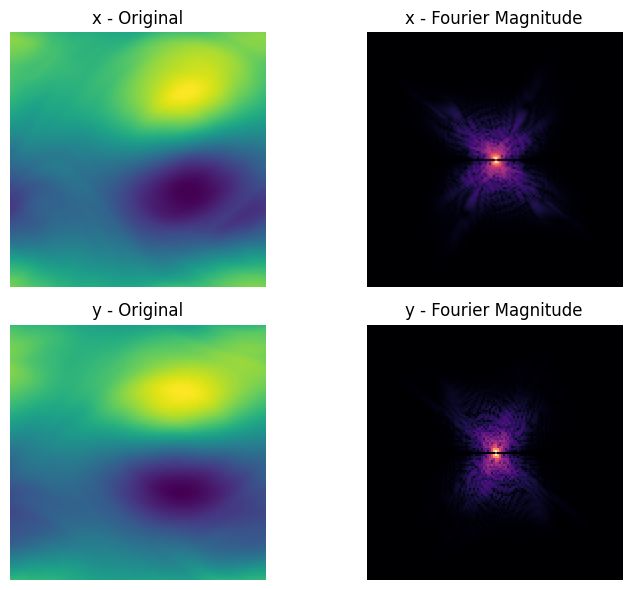

In [ ]:
import torch.fft

for i, (x, y) in enumerate(dataloader):
    x, y = x.cuda(), y.cuda()

    # Example: visualize first sample in batch
    x_sample = x[0].detach().cpu()  # shape [2, 2, 128, 128]
    y_sample = y[0].detach().cpu()

    # Select one channel to visualize (e.g., channel 0, component 0)
    x_vis = x_sample[0, 0]  # shape [128, 128]
    y_vis = y_sample[0, 0]

    # Compute 2D Fourier transforms and take magnitude
    x_fft = torch.fft.fftshift(torch.fft.fft2(x_vis))
    y_fft = torch.fft.fftshift(torch.fft.fft2(y_vis))
    x_fft_mag = x_fft.abs().log1p()
    y_fft_mag = y_fft.abs().log1p()

    # Plot
    fig, axs = plt.subplots(2, 2, figsize=(8, 6))

    axs[0, 0].imshow(x_vis, cmap='viridis')
    axs[0, 0].set_title('x - Original')
    axs[0, 1].imshow(x_fft_mag, cmap='magma')
    axs[0, 1].set_title('x - Fourier Magnitude')

    axs[1, 0].imshow(y_vis, cmap='viridis')
    axs[1, 0].set_title('y - Original')
    axs[1, 1].imshow(y_fft_mag, cmap='magma')
    axs[1, 1].set_title('y - Fourier Magnitude')

    for ax in axs.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    break  # remove this if you want to see more batches

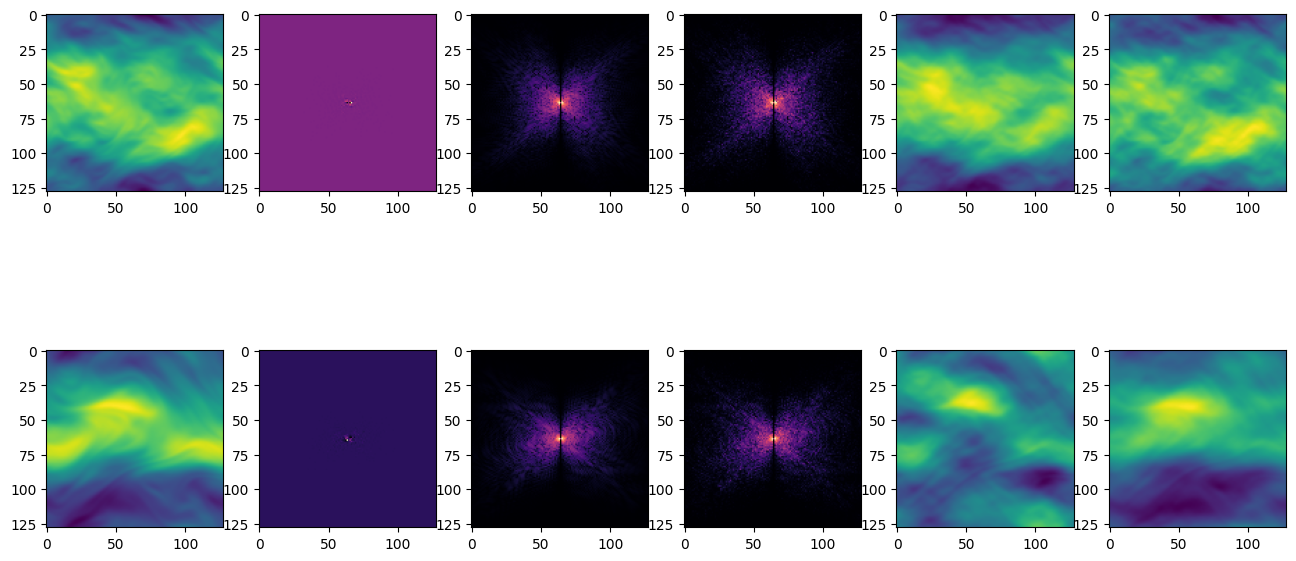

In [ ]:
for i, (x, y) in enumerate(dataloader):
    x, y = x.cuda(), y.cuda()
    # fourier space
    break

x_fft = torch.fft.fftshift(torch.fft.fft2(x, dim=(-2, -1)))
y_fft = torch.fft.fftshift(torch.fft.fft2(y, dim=(-2, -1)))

x_fft_mag = x_fft.abs().log1p()
y_fft_mag = y_fft.abs().log1p()
x_fft_phase = torch.angle(x_fft)
y_fft_phase = torch.angle(y_fft)

# perturb?\
perturbation_strength = 0.8
x_fft = x_fft * torch.exp(1j * torch.randn_like(x_fft) * perturbation_strength)
y_fft = y_fft * torch.exp(1j * torch.randn_like(y_fft) * perturbation_strength)
x_fft_mag2 = x_fft.abs().log1p()
y_fft_mag2 = y_fft.abs().log1p()

x_recon = torch.fft.ifft2(torch.fft.ifftshift(x_fft)).real
y_recon = torch.fft.ifft2(torch.fft.ifftshift(y_fft)).real

def random_fft_perturb(x, perturbation_strength=0.4):
    x_fft = torch.fft.fftshift(torch.fft.fft2(x, dim=(-2, -1)))
    x_fft = x_fft * torch.exp(1j * torch.randn_like(x_fft) * perturbation_strength)
    x_recon = torch.fft.ifft2(torch.fft.ifftshift(x_fft)).real
    return x_recon

x_recon2 = random_fft_perturb(x, perturbation_strength=perturbation_strength)
y_recon2 = random_fft_perturb(y, perturbation_strength=perturbation_strength)

fig, axs = plt.subplots(2, 6, figsize=(16, 8))
axs[0, 0].imshow(x[0, 0, 0].cpu(), cmap='viridis')
axs[0, 1].imshow(x_fft[0, 0, 0].real.cpu(), cmap='magma')
axs[0, 2].imshow(x_fft_mag[0, 0, 0].cpu(), cmap='magma')
axs[0, 3].imshow(x_fft_mag2[0, 0, 0].cpu(), cmap='magma')
axs[0, 4].imshow(x_recon[0, 0, 0].cpu(), cmap='viridis')
axs[0, 5].imshow(x_recon2[0, 0, 0].cpu(), cmap='viridis')

axs[1, 0].imshow(y[0, 0, 0].cpu(), cmap='viridis')
axs[1, 1].imshow(y_fft[0, 0, 0].real.cpu(), cmap='magma')
axs[1, 2].imshow(y_fft_mag[0, 0, 0].cpu(), cmap='magma')
axs[1, 3].imshow(y_fft_mag2[0, 0, 0].cpu(), cmap='magma')
axs[1, 4].imshow(y_recon[0, 0, 0].cpu(), cmap='viridis')
axs[1, 5].imshow(y_recon2[0, 0, 0].cpu(), cmap='viridis')
plt.show()

In [ ]:

def random_fft_perturb(x, perturbation_strength=0.4):
    x_fft = torch.fft.fftshift(torch.fft.fft2(x, dim=(-2, -1)))
    x_fft = x_fft * torch.exp(1j * torch.randn_like(x_fft) * perturbation_strength)
    x_recon = torch.fft.ifft2(torch.fft.ifftshift(x_fft)).real
    return x_recon


In [ ]:
shifts = [
        (0, 1),    # right
        (0, -1),   # left
        (1, 0),    # down
        (-1, 0),   # up
        (1, 1),    # down-right
        (-1, -1),  # up-left
        (-1, 1),   # up-right
        (1, -1),   # down-left
        (0, 0)     # no shift
    ]
def random_roll_tensor(tensor, how_many=1):
    for _ in range(how_many):
        dy, dx = shifts[torch.randint(len(shifts), (1,)).item()]
        tensor = torch.roll(tensor, shifts=(dy, dx), dims=(-2, -1))
    return tensor
